---
## Step 0 — Setup and install Libraries ##

In [1]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Step 1 — Load the Data ##

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('vgsales.csv')
df.head()

---
## Step 2 — Exploratory vs Explanatory ##

*What is the difference?* (Hint: Exploratory is like a detective finding clues; explanatory is like a storyteller presenting the final answer).

*Which one are you producing in this assignment?* (Be honest—usually, when we are just playing with a new dataset, it's exploratory).

(Hint: Think about why you should look at a chart instead of just looking at the average or mean of the sales).

**Task 2.1**

Difference: Exploratory visualization is used to find patterns or anomalies in data during the analysis phase (it’s for me), while explanatory visualization is used to communicate a specific insight or story to an audience (it’s for them).

What I am producing: I am producing exploratory visualizations in this assignment because I am still investigating the vgsales dataset to understand its distributions and correlations.

**Task 2.2 — Anscombe’s Quartet**

The lecture mentions Anscombe’s Quartet to prove that summary statistics (like mean and variance) can be identical for very different datasets, so we must visualize data to see the true patterns.

---
## Step 3 — Matplotlib and Seaborn ##

**Task 3.1 — Plain Matplotlib**

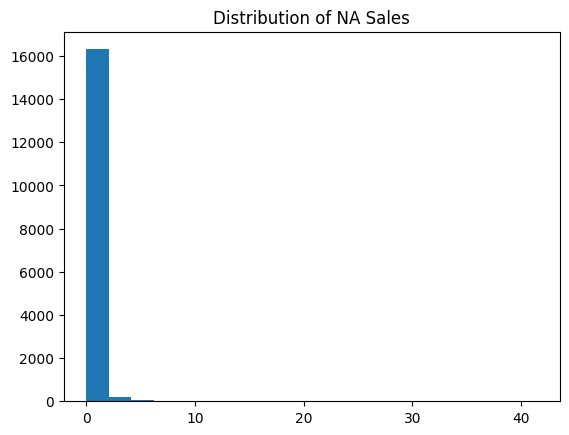

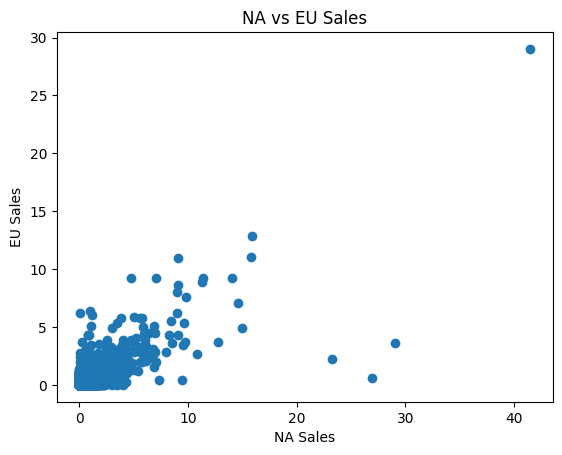

In [ ]:
import matplotlib.pyplot as plt

# Histogram of North American Sales
plt.hist(df["NA_Sales"], bins=20)
plt.title("Distribution of NA Sales")
plt.show()

# Scatter plot: NA Sales vs EU Sales
plt.scatter(df["NA_Sales"], df["EU_Sales"])
plt.xlabel("NA Sales")
plt.ylabel("EU Sales")
plt.title("NA vs EU Sales")
plt.show()

**Task 3.2 — Seaborn**

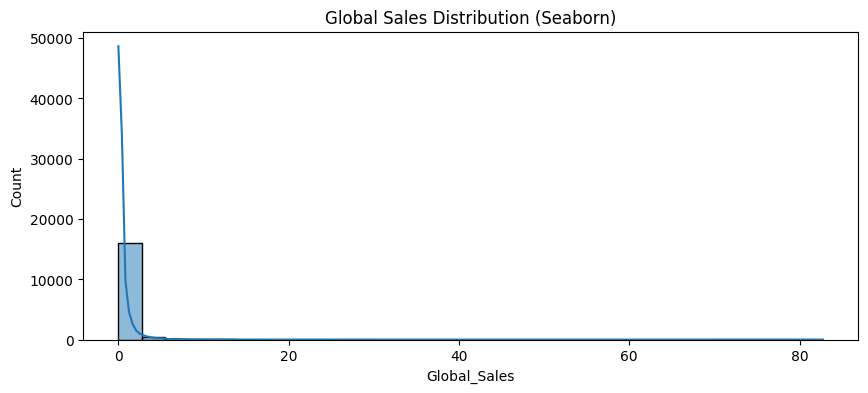

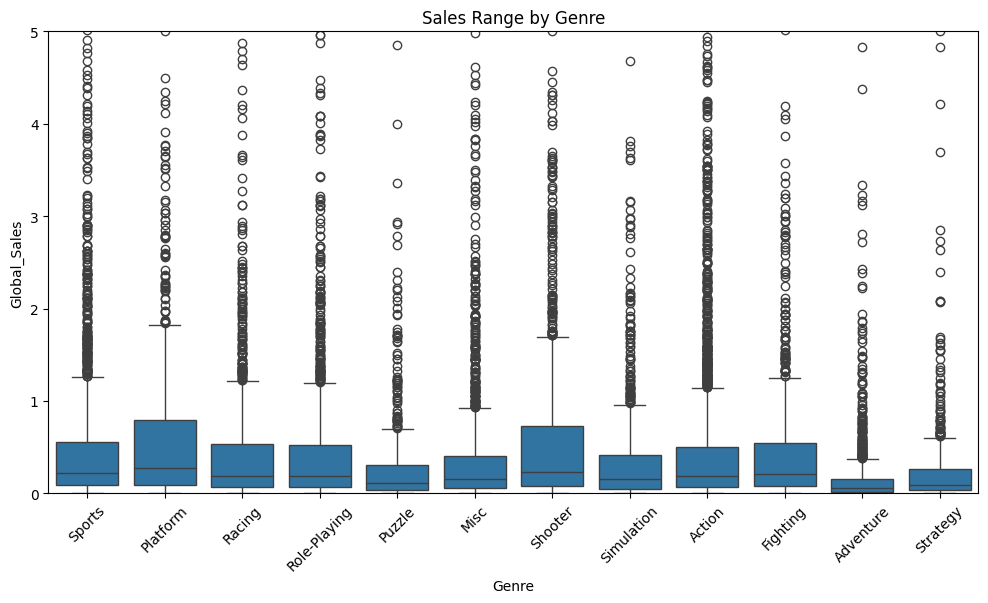

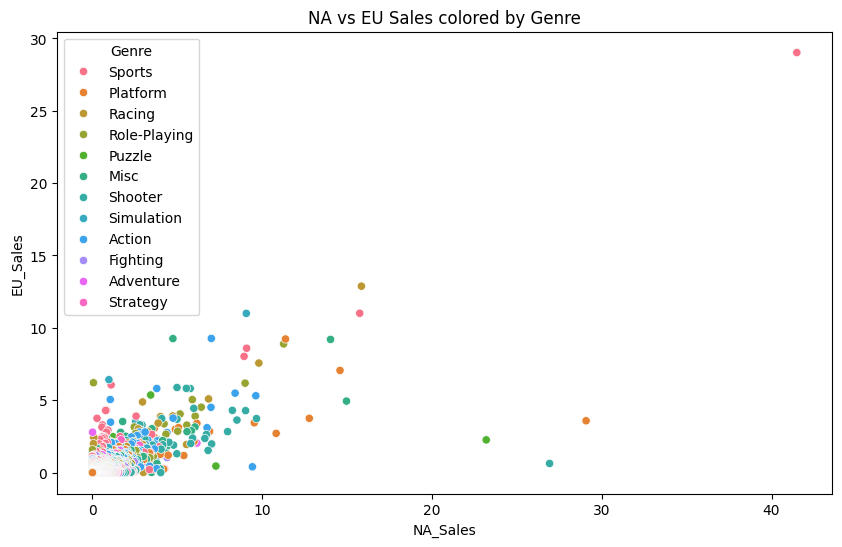

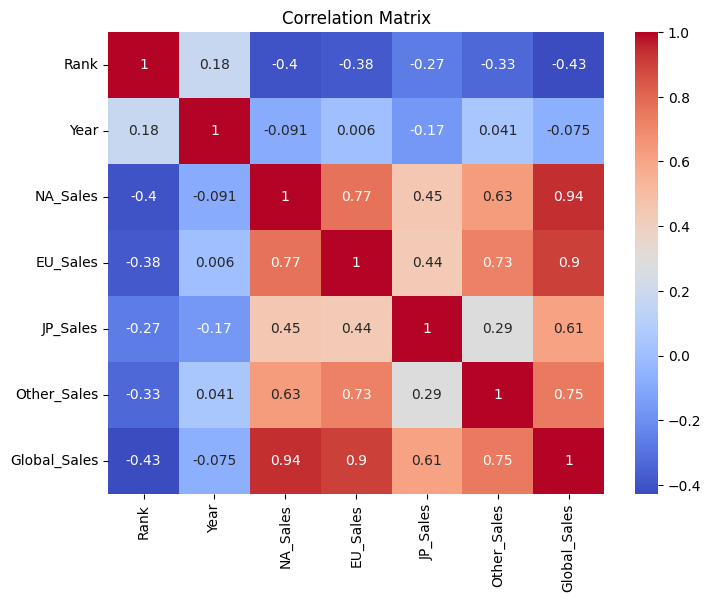

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Histogram with a KDE (line showing the shape)
plt.figure(figsize=(10, 4))
sns.histplot(df, x="Global_Sales", kde=True, bins=30)
plt.title("Global Sales Distribution (Seaborn)")
plt.show()

# 2. Boxplot to see sales by Genre
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Genre", y="Global_Sales")
plt.xticks(rotation=45) # Rotates labels so they don't overlap
plt.title("Sales Range by Genre")
plt.ylim(0, 5) # Zooming in because of the outliers
plt.show()

# 3. Scatterplot with 'hue' (Coloring points by Genre)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="NA_Sales", y="EU_Sales", hue="Genre")
plt.title("NA vs EU Sales colored by Genre")
plt.show()

# 4. Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**Task 3.3 — OO Matplotlib for control**

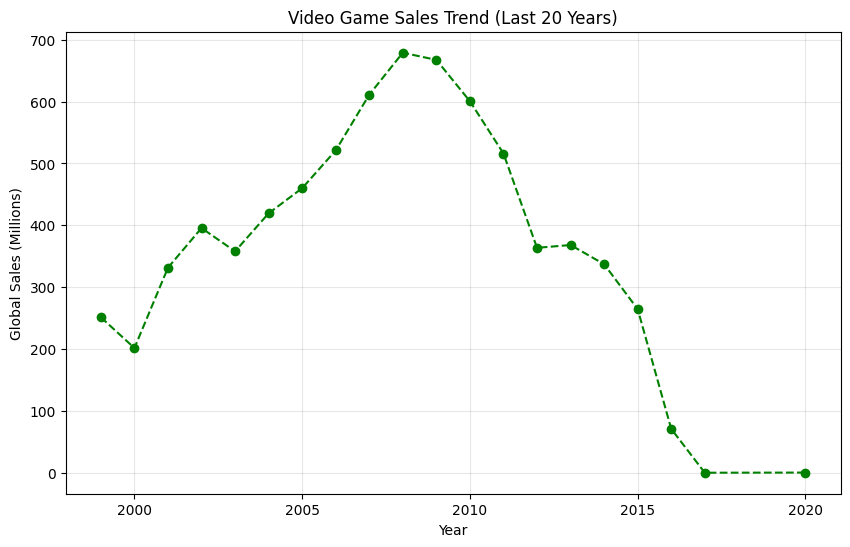

In [ ]:
# We'll plot total sales per year to see the trend
yearly_sales = df.groupby('Year')['Global_Sales'].sum().tail(20) # Last 20 years

# The Object-Oriented Pattern
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(yearly_sales.index, yearly_sales.values, marker='o', color='green', linestyle='--')

# Customizing with the 'ax' object
ax.set_xlabel("Year")
ax.set_ylabel("Global Sales (Millions)")
ax.set_title("Video Game Sales Trend (Last 20 Years)")
ax.grid(True, alpha=0.3)

# Save it to a file (This is a deliverable!)
fig.savefig("out.png", dpi=150)

plt.show()

---
## Step 4 — Five Rules for Honest Charts ##

**Task 4.1: The Audit**



| Rule | Yes / No / N/A | Explanation |
| :--- | :---: | :--- |
| **1. Are axes labelled with units?** | Yes | The x-axis is labeled "Year" and the y-axis specifies units in "Millions". |
| **2. Does the y-axis start at zero?** | N/A | This is a line chart, but the y-axis starts at zero, ensuring the scale is not misleading. |
| **3. Is it the right chart type?** | Yes | A line chart is the ideal choice for visualizing trends and changes over a continuous time period. |
| **4. Is there any chartjunk?** | No | The visualization is clean, with no 3D effects, shadows, or unnecessary decorative elements. |
| **5. Does it carry one clear message?** | Yes | The chart clearly communicates the historical rise and recent trend of global video game sales. |

**Task 4.2 (Log scale)**

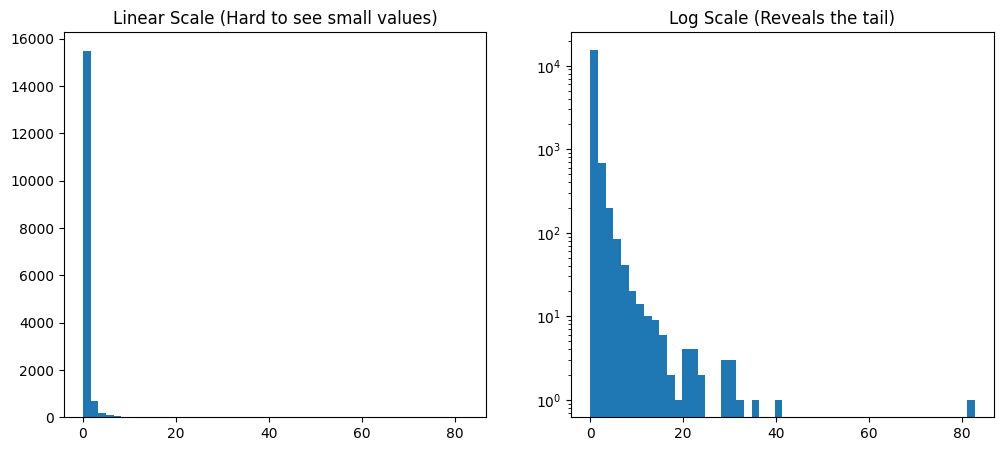

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Linear Scale (Normal)
ax1.hist(df["Global_Sales"], bins=50)
ax1.set_title("Linear Scale (Hard to see small values)")

# 2. Log Scale (Y-axis logaritmik)
ax2.hist(df["Global_Sales"], bins=50)
ax2.set_yscale("log")
ax2.set_title("Log Scale (Reveals the tail)")

plt.show()

**Assignment has been completed successfully**